# Desarrollo de Entrega Unidad 5 – Base de Datos de tienda usando las Unidades 11 y 12
# Analizando base de datos sobre obesidad

Implementar modelos de clasificación o de regresión

Importamos Librerias

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import plotly.express as px
import plotly.graph_objects as go
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Cargando y Analizando la Base de datos
Ahora importamos nuestra base de datos

In [48]:
obesity_data = pd.read_csv('data/obesity_dataset.csv')
#obesity_data.rename(columns={'Gender':'Genero','Age':'Edad','Height':'Altura','Weight':'Peso','family_history_with_overweight':'Historia_Familia_peso','FAVC':'CAAC','FCVC':'Consumo_Veg','NCP':'Num_Com','CAEC':'Con_Entre_C','SMOKE':'FUMA','CH2O':'Consum_Agua'},inplace=True)
obesity_data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [49]:

obesity_data.describe ()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [50]:
obesity_data.dtypes
obesity_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [51]:
obesity_data.isna().sum()

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

# Eliminar los datos duplicados 

In [52]:
obesity_data = obesity_data.drop_duplicates().reset_index(drop=True)
obesity_data


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2083,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2084,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2085,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [63]:
cols_redondear = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
obesity_data[cols_redondear] = obesity_data[cols_redondear].round(2)
obesity_data['Age'] = obesity_data['Age'].round(0).astype(int)
obesity_data['NCP'] = obesity_data['NCP'].round(0).astype(int)
obesity_data[cols_redondear].head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
0,21,1.62,64.0,2.0,3,2.0,0.0,1.0
1,21,1.52,56.0,3.0,3,3.0,3.0,0.0
2,23,1.80,77.0,2.0,3,2.0,2.0,1.0
3,27,1.80,87.0,3.0,3,2.0,2.0,0.0
4,22,1.78,89.8,2.0,1,2.0,0.0,0.0


In [64]:
obesity_data['IMC'] = (obesity_data['Weight'] / (obesity_data['Height'] ** 2)).round(2)
obesity_data.groupby('NObeyesdad')['IMC'].agg(['min', 'max', 'mean']).sort_values('mean')

,min,max,mean
NObeyesdad,,,
Insufficient_Weight,13.00,19.10,17.392622
Normal_Weight,18.49,24.91,22.007908
Overweight_Level_I,22.86,28.71,25.949420
Overweight_Level_II,25.69,30.36,28.212517
Obesity_Type_I,29.81,35.27,32.269430
Obesity_Type_II,33.89,39.81,36.721987
Obesity_Type_III,36.61,50.82,42.286852


## Preguntas de análisis exploratorio

1. ¿Los hábitos alimenticios (FAVC) y de actividad física (FAF) se relacionan con el nivel de obesidad?
2. ¿El historial familiar de sobrepeso es un factor determinante, y cómo interactúa con los hábitos?
3. ¿El medio de transporte habitual influye en el nivel de obesidad?

# Analisis EDA

**Decisión de modelado:** para que el ejercicio sea analíticamente útil, se entrenarán los
modelos **sin** `Weight`, `Height` e `IMC`, usando únicamente variables demográficas y de
hábitos (alimentación, actividad física, transporte, consumo de agua/alcohol, etc.). Esto
permite responder una pregunta más interesante: *¿qué tan bien predicen los hábitos de una
persona su nivel de obesidad, sin conocer su peso?* 

**Pregunta base** ¿que relación tiene El nivel de obesidad directamente de los habitos cotidianos y como esta directarectamente relacionado su predisposición genetica según la condición de peso de la familia?

In [65]:
obesity_data['IMC'] = (obesity_data['Weight'] / (obesity_data['Height'] ** 2)).round(2)
obesity_data.groupby('NObeyesdad')['IMC'].agg(['min', 'max', 'mean']).sort_values('mean')


,min,max,mean
NObeyesdad,,,
Insufficient_Weight,13.00,19.10,17.392622
Normal_Weight,18.49,24.91,22.007908
Overweight_Level_I,22.86,28.71,25.949420
Overweight_Level_II,25.69,30.36,28.212517
Obesity_Type_I,29.81,35.27,32.269430
Obesity_Type_II,33.89,39.81,36.721987
Obesity_Type_III,36.61,50.82,42.286852


In [66]:
obesity_data.shape  
obesity_data

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,IMC
0,Female,21,1.62,64.00,yes,no,2.0,3,Sometimes,no,2.00,no,0.00,1.00,no,Public_Transportation,Normal_Weight,24.39
1,Female,21,1.52,56.00,yes,no,3.0,3,Sometimes,yes,3.00,yes,3.00,0.00,Sometimes,Public_Transportation,Normal_Weight,24.24
2,Male,23,1.80,77.00,yes,no,2.0,3,Sometimes,no,2.00,no,2.00,1.00,Frequently,Public_Transportation,Normal_Weight,23.77
3,Male,27,1.80,87.00,no,no,3.0,3,Sometimes,no,2.00,no,2.00,0.00,Frequently,Walking,Overweight_Level_I,26.85
4,Male,22,1.78,89.80,no,no,2.0,1,Sometimes,no,2.00,no,0.00,0.00,Sometimes,Public_Transportation,Overweight_Level_II,28.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2082,Female,21,1.71,131.41,yes,yes,3.0,3,Sometimes,no,1.73,no,1.68,0.91,Sometimes,Public_Transportation,Obesity_Type_III,44.94
2083,Female,22,1.75,133.74,yes,yes,3.0,3,Sometimes,no,2.01,no,1.34,0.60,Sometimes,Public_Transportation,Obesity_Type_III,43.67
2084,Female,23,1.75,133.69,yes,yes,3.0,3,Sometimes,no,2.05,no,1.41,0.65,Sometimes,Public_Transportation,Obesity_Type_III,43.65
2085,Female,24,1.74,133.35,yes,yes,3.0,3,Sometimes,no,2.85,no,1.14,0.59,Sometimes,Public_Transportation,Obesity_Type_III,44.04


In [67]:
# Binarias (yes/no)
binarias = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']

# Ordinales (tienen un orden natural: no < Sometimes < Frequently < Always)
ordinales = ['CAEC', 'CALC']

# Nominales (no tienen orden: se codifican con One-Hot)
nominales = ['Gender', 'MTRANS']

C:\Users\adolp\AppData\Local\Temp\ipykernel_35684\2432478971.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=obesity_data, y='NObeyesdad', order=order, palette='viridis')


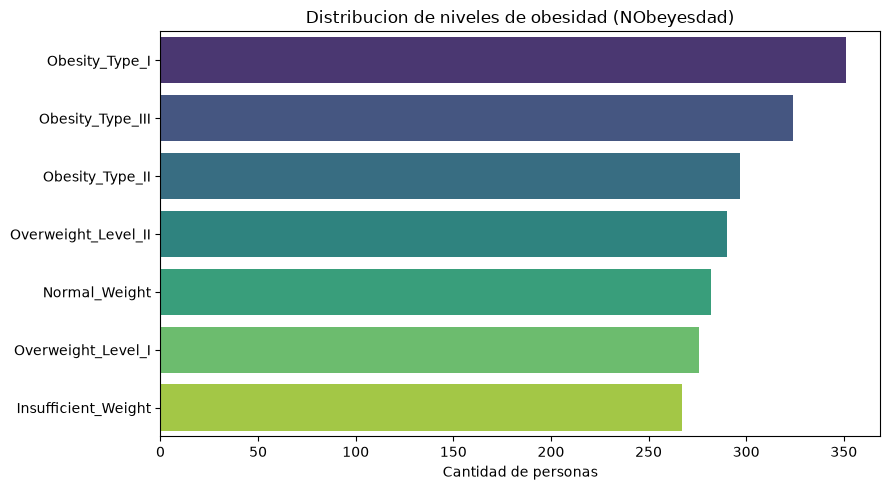

In [68]:
plt.figure(figsize=(9,5))
order = obesity_data['NObeyesdad'].value_counts().index
sns.countplot(data=obesity_data, y='NObeyesdad', order=order, palette='viridis')
plt.title('Distribucion de niveles de obesidad (NObeyesdad)')
plt.xlabel('Cantidad de personas')
plt.ylabel('')
plt.tight_layout()
plt.savefig('01_distribucion_clases.png')
plt.show()

C:\Users\adolp\AppData\Local\Temp\ipykernel_35684\1644737631.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=obesity_data, x='NObeyesdad', y='FAF', order=order_cat, ax=axes[0], palette='coolwarm')


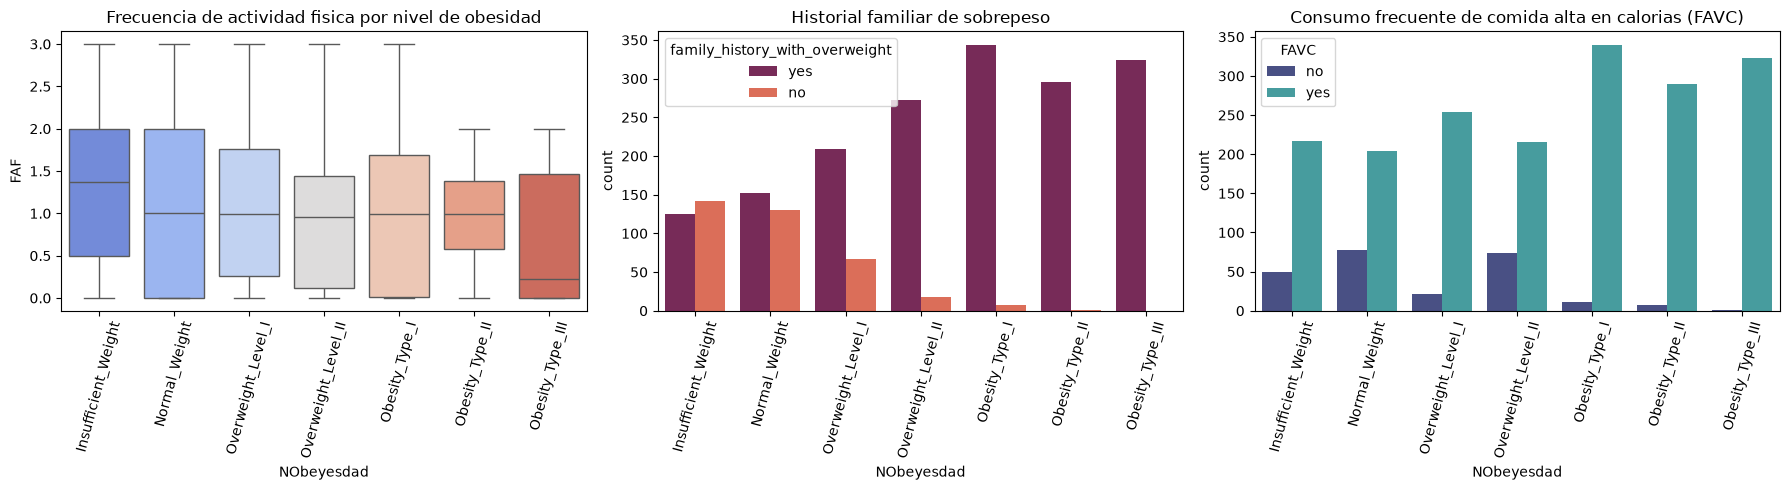

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

order_cat = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I',
             'Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']

sns.boxplot(data=obesity_data, x='NObeyesdad', y='FAF', order=order_cat, ax=axes[0], palette='coolwarm')
axes[0].set_title('Frecuencia de actividad fisica por nivel de obesidad')
axes[0].tick_params(axis='x', rotation=75)

sns.countplot(data=obesity_data, x='NObeyesdad', hue='family_history_with_overweight',
              order=order_cat, ax=axes[1], palette='rocket')
axes[1].set_title('Historial familiar de sobrepeso')
axes[1].tick_params(axis='x', rotation=75)

sns.countplot(data=obesity_data, x='NObeyesdad', hue='FAVC',
              order=order_cat, ax=axes[2], palette='mako')
axes[2].set_title('Consumo frecuente de comida alta en calorias (FAVC)')
axes[2].tick_params(axis='x', rotation=75)

plt.tight_layout()
plt.savefig('03_habitos_por_clase.png')
plt.show()